In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
print(torch.cuda.device_count())


x = torch.randn(3, 3, device="cuda")
y = x @ x
print(x)
print(y)



1
tensor([[ 0.4212, -1.8480, -0.4531],
        [ 1.8941, -0.8992, -1.2071],
        [ 1.1839, -1.2321, -0.1680]], device='cuda:0')
tensor([[-3.8594,  1.4417,  2.1161],
        [-2.3346, -1.2044,  0.4301],
        [-2.0339, -0.8730,  0.9791]], device='cuda:0')


In [2]:
import haiku as hk
import jax
import jax.numpy as jnp
from nucleotide_transformer.pretrained import get_pretrained_model

# Get pretrained model
parameters, forward_fn, tokenizer, config = get_pretrained_model(
    model_name="1B_agro_nt",
    embeddings_layers_to_save=(12,),
    max_positions=32,
)
forward_fn = hk.transform(forward_fn)


/home/htamm/miniconda3/envs/agront/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded model's hyperparameters.
Downloaded model's weights...


In [3]:
# Get data and tokenize it
sequences = ["GGACAGCGG", "GGACGGCGG"]
tokens_ids = [b[1] for b in tokenizer.batch_tokenize(sequences)]
tokens = jnp.asarray(tokens_ids, dtype=jnp.int32)

# Initialize random key
random_key = jax.random.PRNGKey(0)

# Inference
outs = forward_fn.apply(parameters, random_key, tokens)

# Get embeddings at layer 20
print(outs["embeddings_12"].shape)

(2, 32, 1500)


In [6]:
print(outs["embeddings_12"][0])
print(outs["embeddings_12"][1])
#print(outs["embeddings_12"])


[[ 0.50518507 -7.5023365   4.156925   ...  0.7522291  -2.6433825
  -4.6690855 ]
 [ 2.9224174  -8.604653   11.098467   ...  4.309381    0.0933643
  -6.024859  ]
 [ 6.6602054  -7.1872215  14.583445   ...  6.813944    1.7326771
  -3.9323466 ]
 ...
 [14.540912    2.1560988  22.828514   ... 13.610388   10.634382
   3.1043367 ]
 [14.540912    2.1560988  22.828514   ... 13.610388   10.634382
   3.1043367 ]
 [14.540912    2.1560988  22.828514   ... 13.610388   10.634382
   3.1043367 ]]
[[ 0.46740878 -5.8439293   3.6012642  ...  0.97687227  0.46474624
  -3.305413  ]
 [ 4.8344     -3.941904   11.822891   ...  4.1446056   0.29869008
  -5.0827765 ]
 [ 6.3979445  -5.442378   16.214565   ...  8.687018    1.2993034
  -3.6606305 ]
 ...
 [15.2234      1.9138956  23.077442   ... 13.757053   10.614
   3.0552905 ]
 [15.2234      1.9138956  23.077442   ... 13.757053   10.614
   3.0552905 ]
 [15.2234      1.9138956  23.077442   ... 13.757053   10.614
   3.0552905 ]]


In [7]:
from pathlib import Path
from typing import Dict, List

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np

from nucleotide_transformer.pretrained import get_pretrained_model


# ---------------------------------------------------------------------------
# FASTA-Handling
# ---------------------------------------------------------------------------

def read_fasta_sequences(path: Path) -> List[str]:
    """Sehr einfacher FASTA-Parser ohne zusätzliche Bibliotheken."""
    sequences: List[str] = []
    current: List[str] = []

    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current:
                    sequences.append("".join(current).upper())
                    current = []
            else:
                current.append(line)
        if current:
            sequences.append("".join(current).upper())

    return sequences


def collect_all_sequences(fasta_dir: Path) -> Dict[str, List[str]]:
    """Liest alle FASTA-Dateien in einem Verzeichnis und gibt ein Dict zurück."""
    fasta_files = sorted(list(fasta_dir.glob("*.fa*")))
    if not fasta_files:
        raise FileNotFoundError(f"Keine FASTA-Dateien in {fasta_dir} gefunden.")

    all_data: Dict[str, List[str]] = {}
    for fasta_file in fasta_files:
        seqs = read_fasta_sequences(fasta_file)
        if not seqs:
            print(f"Warnung: Keine Sequenzen in {fasta_file} gefunden.")
            continue
        all_data[fasta_file.name] = seqs

    if not all_data:
        raise RuntimeError("Es wurden zwar FASTA-Dateien gefunden, aber keine Sequenzen.")
    return all_data


# ---------------------------------------------------------------------------
# Modell & Embeddings
# ---------------------------------------------------------------------------

def load_agront_model(max_len: int,
                      model_name: str = "1B_agro_nt",
                      layer_to_save: int = 12):
    """Lädt das AgroNT-Modell mit gewünschter maximaler Position und Layer-Ausgabe."""
    print(f"Lade Modell '{model_name}' mit max_positions={max_len} ...")
    parameters, forward_fn, tokenizer, config = get_pretrained_model(
        model_name=model_name,
        embeddings_layers_to_save=(layer_to_save,),
        max_positions=max_len,
    )
    forward_fn = hk.transform(forward_fn)
    return parameters, forward_fn, tokenizer, config


def get_last_layer_embeddings(
    sequences: List[str],
    parameters,
    forward_fn,
    tokenizer,
    rng_key,
    layer_to_save: int,
) -> np.ndarray:
    """Berechnet die Embeddings des gewünschten Layers für eine Liste von Sequenzen."""
    token_ids = [b[1] for b in tokenizer.batch_tokenize(sequences)]
    tokens = jnp.asarray(token_ids, dtype=jnp.int32)  # (batch, seq_len)

    outs = forward_fn.apply(parameters, rng_key, tokens)
    key = f"embeddings_{layer_to_save}"
    if key not in outs:
        raise KeyError(f"{key} nicht im Model-Output gefunden. Verfügbare Keys: {list(outs.keys())}")

    emb = outs[key]  # (batch, seq_len, hidden_dim)
    return np.array(emb)


# ---------------------------------------------------------------------------
# Embedding-Reduktion (Pooling)
# ---------------------------------------------------------------------------

def mean_pool_sequence(emb_last_layer: np.ndarray) -> np.ndarray:
    """Mean-Pooling über die Sequenzdimension."""
    return emb_last_layer.mean(axis=1)


def get_middle_position_embedding(emb_last_layer: np.ndarray) -> np.ndarray:
    """Embedding an der mittleren Position der Sequenz."""
    batch, seq_len, hidden_dim = emb_last_layer.shape
    mid_idx = seq_len // 2
    return emb_last_layer[:, mid_idx, :]


# ---------------------------------------------------------------------------
# Ähnlichkeits- und Distanzmetriken
# ---------------------------------------------------------------------------

def cosine_similarity_matrix(X: np.ndarray) -> np.ndarray:
    """Cosine-Similarity-Matrix für alle Paare in X."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / (norms + 1e-12)
    return X_norm @ X_norm.T


def euclidean_distance_matrix(X: np.ndarray) -> np.ndarray:
    """Euklidische Distanzen für alle Paare in X."""
    sq = np.sum(X ** 2, axis=1, keepdims=True)
    sq_mat = sq + sq.T - 2 * (X @ X.T)
    sq_mat = np.maximum(sq_mat, 0.0)
    return np.sqrt(sq_mat)


def summarize_matrix(name: str, M: np.ndarray):
    """Gibt einige Kennzahlen für eine Matrix aus (min, max, Mittelwert)."""
    n = M.shape[0]
    if n <= 1:
        print(f"{name}: Matrix zu klein für sinnvolle Statistik (n={n}).")
        return

    mask = ~np.eye(n, dtype=bool)
    vals = M[mask]

    print(f"{name}:")
    print(f"  Shape: {M.shape}")
    print(f"  Min:   {vals.min():.4f}")
    print(f"  Max:   {vals.max():.4f}")
    print(f"  Mean:  {vals.mean():.4f}")


# ---------------------------------------------------------------------------
# Nur GLOBALE Analyse über alle Sequenzen
# ---------------------------------------------------------------------------

def run_global_agront_analysis(
    fasta_dir: str = "/home/htamm/models/agront/nucleotide-transformer/notebooks/fasta_files",
    model_name: str = "1B_agro_nt",
    layer: int = 12,
):
    """
    Globale Analyse:

    - Liest alle FASTA-Dateien im Verzeichnis.
    - Berechnet Embeddings für alle Sequenzen gemeinsam.
    - Gibt globale Similarity-/Distanz-Kennzahlen aus.
    """
    fasta_dir_path = Path(fasta_dir)
    if not fasta_dir_path.is_dir():
        raise NotADirectoryError(f"{fasta_dir_path} ist kein Verzeichnis.")

    print(f"Suche FASTA-Dateien in: {fasta_dir_path}")
    all_sequences_per_file = collect_all_sequences(fasta_dir_path)

    # Alle Sequenzen + Labels einsammeln
    all_labels = []          # (Dateiname, Länge)
    all_seqs_global: List[str] = []

    for fname, seqs in all_sequences_per_file.items():
        for s in seqs:
            all_labels.append((fname, len(s)))
            all_seqs_global.append(s)

    print("Reihenfolge der Sequenzen:")
    for idx, (fname, length) in enumerate(all_labels):
        print(f"  Index {idx}: Datei={fname}, Länge={length}")

    # Maximale Länge bestimmen
    max_len = max(len(s) for s in all_seqs_global)
    print(f"\nMaximale Sequenzlänge über alle Dateien: {max_len}")

    # Modell laden
    parameters, forward_fn, tokenizer, config = load_agront_model(
        max_len=max_len,
        model_name=model_name,
        layer_to_save=layer,
    )

    # Fixer Random Key
    rng = jax.random.PRNGKey(0)

    # Embeddings für ALLE Sequenzen
    emb_all = get_last_layer_embeddings(
        sequences=all_seqs_global,
        parameters=parameters,
        forward_fn=forward_fn,
        tokenizer=tokenizer,
        rng_key=rng,
        layer_to_save=layer,
    )  # (N, seq_len, hidden_dim)
    N, seq_len_all, hidden_dim_all = emb_all.shape
    print(f"\nGlobale Embeddings-Shape: (N={N}, seq_len={seq_len_all}, hidden_dim={hidden_dim_all})")

    # Mean-pooled
    pooled_all = mean_pool_sequence(emb_all)        # (N, hidden_dim)
    cos_pooled_all = cosine_similarity_matrix(pooled_all)
    dist_pooled_all = euclidean_distance_matrix(pooled_all)

    summarize_matrix("GLOBAL Mean-pooled Cosine-Similarity", cos_pooled_all)
    summarize_matrix("GLOBAL Mean-pooled euklidische Distanz", dist_pooled_all)

    # Middle-Position
    middle_all = get_middle_position_embedding(emb_all)  # (N, hidden_dim)
    cos_middle_all = cosine_similarity_matrix(middle_all)
    dist_middle_all = euclidean_distance_matrix(middle_all)

    summarize_matrix("GLOBAL Middle-Position Cosine-Similarity", cos_middle_all)
    summarize_matrix("GLOBAL Middle-Position euklidische Distanz", dist_middle_all)

    print("\nAnalyse abgeschlossen.")

    # Optional: Ergebnisse zurückgeben, falls du später damit weiterrechnen/plotten willst
    return {
        "labels": all_labels,
        "cos_pooled": cos_pooled_all,
        "dist_pooled": dist_pooled_all,
        "cos_middle": cos_middle_all,
        "dist_middle": dist_middle_all,
    }


# ---------------------------------------------------------------------------
# Aufruf
# ---------------------------------------------------------------------------

FASTA_DIR = "/home/htamm/models/agront/nucleotide-transformer/notebooks/fasta_files"
MODEL_NAME = "1B_agro_nt"
LAYER = 12

results = run_global_agront_analysis(
    fasta_dir=FASTA_DIR,
    model_name=MODEL_NAME,
    layer=LAYER,
)


Suche FASTA-Dateien in: /home/htamm/models/agront/nucleotide-transformer/notebooks/fasta_files
Reihenfolge der Sequenzen:
  Index 0: Datei=Accession_7063_chr4_3760968_3761027.fasta, Länge=60
  Index 1: Datei=Accession_7063_chr4_3760971_3761024.fasta, Länge=54
  Index 2: Datei=Accession_7063_chr4_3760974_3761021.fasta, Länge=48
  Index 3: Datei=Accession_7063_chr4_3760977_3761018.fasta, Länge=42
  Index 4: Datei=Accession_7063_chr4_3760980_3761015.fasta, Länge=36
  Index 5: Datei=Accession_7063_chr4_3760983_3761012.fasta, Länge=30
  Index 6: Datei=Accession_7063_chr4_3760986_3761009.fasta, Länge=24
  Index 7: Datei=Accession_7063_chr4_3760989_3761006.fasta, Länge=18
  Index 8: Datei=Accession_7063_chr4_3760992_3761003.fasta, Länge=12
  Index 9: Datei=Accession_7063_chr4_3760995_3761000.fasta, Länge=6

Maximale Sequenzlänge über alle Dateien: 60
Lade Modell '1B_agro_nt' mit max_positions=60 ...
Downloaded model's hyperparameters.
Downloaded model's weights...

Globale Embeddings-Shape: (

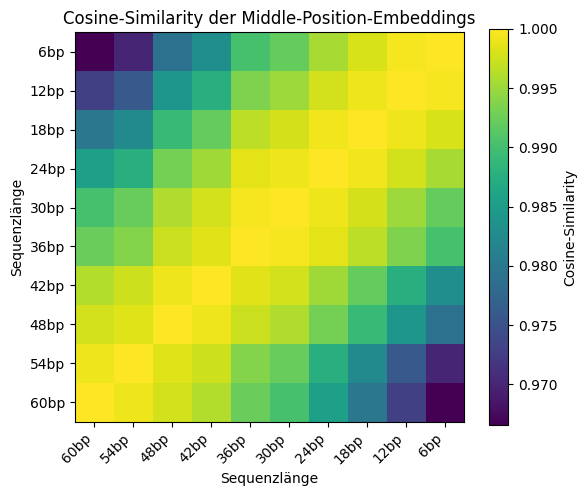

In [ ]:
#heatmap
import matplotlib.pyplot as plt
import numpy as np

# Aus dem vorherigen Schritt:
cos_middle = results["cos_middle"]   # (N, N)
labels = results["labels"]           # Liste von (dateiname, länge)

# Wir nehmen als Achsenbeschriftung nur die Längen (z.B. "60bp", "54bp", ...)
lengths = [length for (_, length) in labels]
ticklabels = [f"{l}bp" for l in lengths]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cos_middle, origin="lower")  # Standard-Colormap

# Achsen-Beschriftung
ax.set_xticks(np.arange(len(ticklabels)))
ax.set_yticks(np.arange(len(ticklabels)))
ax.set_xticklabels(ticklabels, rotation=45, ha="right")
ax.set_yticklabels(ticklabels)

ax.set_xlabel("Sequenzlänge")
ax.set_ylabel("Sequenzlänge")
ax.set_title("Cosine-Similarity der Middle-Position-Embeddings")

# Farbskala
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cosine-Similarity")

plt.tight_layout()
plt.show()


Reihenfolge der Sequenzen:
  Index 0: Datei=Accession_7063_chr4_3760968_3761027.fasta, Länge=60
  Index 1: Datei=Accession_7063_chr4_3760971_3761024.fasta, Länge=54
  Index 2: Datei=Accession_7063_chr4_3760974_3761021.fasta, Länge=48
  Index 3: Datei=Accession_7063_chr4_3760977_3761018.fasta, Länge=42
  Index 4: Datei=Accession_7063_chr4_3760980_3761015.fasta, Länge=36
  Index 5: Datei=Accession_7063_chr4_3760983_3761012.fasta, Länge=30
  Index 6: Datei=Accession_7063_chr4_3760986_3761009.fasta, Länge=24
  Index 7: Datei=Accession_7063_chr4_3760989_3761006.fasta, Länge=18
  Index 8: Datei=Accession_7063_chr4_3760992_3761003.fasta, Länge=12
  Index 9: Datei=Accession_7063_chr4_3760995_3761000.fasta, Länge=6

Maximale Sequenzlänge über alle Dateien: 60
Lade Modell '1B_agro_nt' mit max_positions=60 ...
Downloaded model's hyperparameters.
Downloaded model's weights...
Embeddings-Shape: (N=10, seq_len=60, hidden_dim=1500)


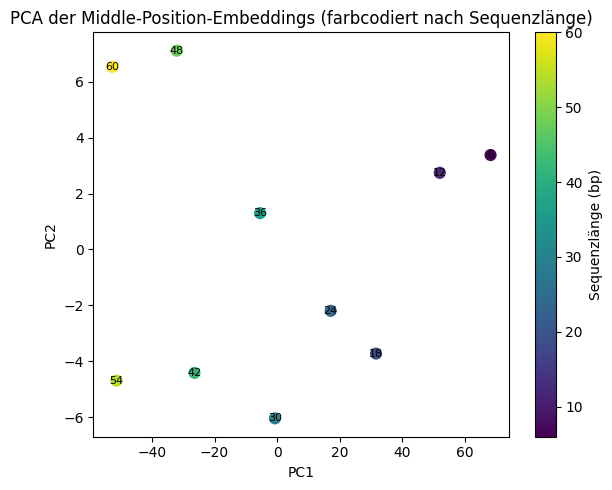

In [ ]:
#PCA
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 1. Sequenzen einlesen ----------

fasta_dir_path = Path(FASTA_DIR)
all_sequences_per_file = collect_all_sequences(fasta_dir_path)

all_labels = []          # (dateiname, länge)
all_seqs_global = []

for fname, seqs in all_sequences_per_file.items():
    for s in seqs:
        all_labels.append((fname, len(s)))
        all_seqs_global.append(s)

lengths = np.array([l for (_, l) in all_labels])

print("Reihenfolge der Sequenzen:")
for idx, (fname, length) in enumerate(all_labels):
    print(f"  Index {idx}: Datei={fname}, Länge={length}")

# ---------- 2. Modell laden & Embeddings berechnen ----------

max_len = max(len(s) for s in all_seqs_global)
print(f"\nMaximale Sequenzlänge über alle Dateien: {max_len}")

parameters, forward_fn, tokenizer, config = load_agront_model(
    max_len=max_len,
    model_name=MODEL_NAME,
    layer_to_save=LAYER,
)

rng = jax.random.PRNGKey(0)

emb_all = get_last_layer_embeddings(
    sequences=all_seqs_global,
    parameters=parameters,
    forward_fn=forward_fn,
    tokenizer=tokenizer,
    rng_key=rng,
    layer_to_save=LAYER,
)  # (N, seq_len, hidden_dim)

N, seq_len_all, hidden_dim_all = emb_all.shape
print(f"Embeddings-Shape: (N={N}, seq_len={seq_len_all}, hidden_dim={hidden_dim_all})")

# ---------- 3. Middle-Position-Embeddings extrahieren ----------

middle_all = get_middle_position_embedding(emb_all)  # (N, hidden_dim)

# ---------- 4. Einfache PCA (2D) via SVD ----------

X = middle_all
X_centered = X - X.mean(axis=0, keepdims=True)

# SVD: X_centered = U * S * V^T
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
components = Vt[:2]              # erste 2 Hauptkomponenten
X_pca = X_centered @ components.T  # (N, 2)

# ---------- 5. Plot ----------

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=60,
    c=lengths,     # Länge als Farbe (Standard-Colormap)
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA der Middle-Position-Embeddings (farbcodiert nach Sequenzlänge)")

cbar = plt.colorbar(scatter)
cbar.set_label("Sequenzlänge (bp)")

# Optional: Punkte beschriften (wenn du nur wenige hast)
for i, (fname, length) in enumerate(all_labels):
    plt.text(
        X_pca[i, 0],
        X_pca[i, 1],
        f"{length}",
        fontsize=8,
        ha="center",
        va="center",
    )

plt.tight_layout()
plt.show()


Reihenfolge der Sequenzen:
  Index 0: Datei=Accession_7063_chr4_3760968_3761027.fasta, Länge=60
  Index 1: Datei=Accession_7063_chr4_3760971_3761024.fasta, Länge=54
  Index 2: Datei=Accession_7063_chr4_3760974_3761021.fasta, Länge=48
  Index 3: Datei=Accession_7063_chr4_3760977_3761018.fasta, Länge=42
  Index 4: Datei=Accession_7063_chr4_3760980_3761015.fasta, Länge=36
  Index 5: Datei=Accession_7063_chr4_3760983_3761012.fasta, Länge=30
  Index 6: Datei=Accession_7063_chr4_3760986_3761009.fasta, Länge=24
  Index 7: Datei=Accession_7063_chr4_3760989_3761006.fasta, Länge=18
  Index 8: Datei=Accession_7063_chr4_3760992_3761003.fasta, Länge=12
  Index 9: Datei=Accession_7063_chr4_3760995_3761000.fasta, Länge=6

Maximale Sequenzlänge über alle Dateien: 60
Lade Modell '1B_agro_nt' mit max_positions=60 ...
Downloaded model's hyperparameters.
Downloaded model's weights...
Embeddings-Shape: (N=10, seq_len=60, hidden_dim=1500)


/home/htamm/miniconda3/envs/agront/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


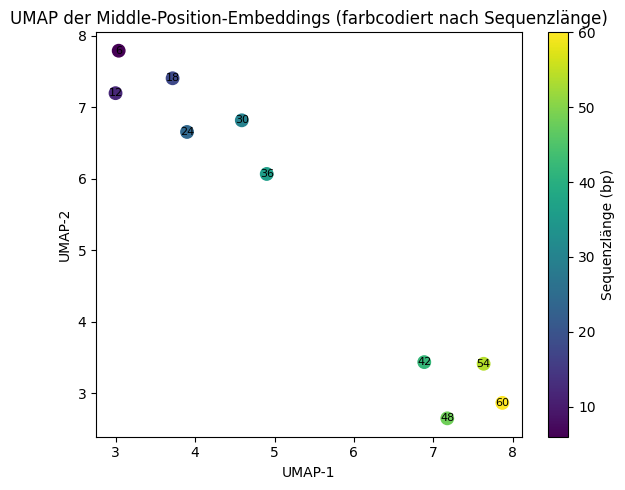

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import umap

# ---------- 1. Sequenzen einlesen ----------

fasta_dir_path = Path(FASTA_DIR)
all_sequences_per_file = collect_all_sequences(fasta_dir_path)

all_labels = []          # (dateiname, länge)
all_seqs_global = []

for fname, seqs in all_sequences_per_file.items():
    for s in seqs:
        all_labels.append((fname, len(s)))
        all_seqs_global.append(s)

lengths = np.array([l for (_, l) in all_labels])

print("Reihenfolge der Sequenzen:")
for idx, (fname, length) in enumerate(all_labels):
    print(f"  Index {idx}: Datei={fname}, Länge={length}")

# ---------- 2. Modell laden & Embeddings berechnen ----------

max_len = max(len(s) for s in all_seqs_global)
print(f"\nMaximale Sequenzlänge über alle Dateien: {max_len}")

parameters, forward_fn, tokenizer, config = load_agront_model(
    max_len=max_len,
    model_name=MODEL_NAME,
    layer_to_save=LAYER,
)

rng = jax.random.PRNGKey(0)

emb_all = get_last_layer_embeddings(
    sequences=all_seqs_global,
    parameters=parameters,
    forward_fn=forward_fn,
    tokenizer=tokenizer,
    rng_key=rng,
    layer_to_save=LAYER,
)  # (N, seq_len, hidden_dim)

N, seq_len_all, hidden_dim_all = emb_all.shape
print(f"Embeddings-Shape: (N={N}, seq_len={seq_len_all}, hidden_dim={hidden_dim_all})")

# ---------- 3. Middle-Position-Embeddings extrahieren ----------

middle_all = get_middle_position_embedding(emb_all)  # (N, hidden_dim)

# ---------- 4. UMAP (2D) ----------

reducer = umap.UMAP(
    n_neighbors=5,     # bei nur 10 Punkten eher klein halten
    min_dist=0.1,
    metric="cosine",   # passt gut zu Embeddings
    random_state=0,
)

X_umap = reducer.fit_transform(middle_all)  # Shape: (N, 2)

# ---------- 5. Plot ----------

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=80,
    c=lengths,
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP der Middle-Position-Embeddings (farbcodiert nach Sequenzlänge)")

cbar = plt.colorbar(scatter)
cbar.set_label("Sequenzlänge (bp)")

# Optional: Punkte mit Länge labeln
for i, (fname, length) in enumerate(all_labels):
    plt.text(
        X_umap[i, 0],
        X_umap[i, 1],
        f"{length}",
        fontsize=8,
        ha="center",
        va="center",
    )

plt.tight_layout()
plt.show()
